# KAMP Press Equipment Anomaly Detection

프레스 유압펌프의 진동·전류 센서 데이터를 이용해 **현재 구간의 정상/이상 상태를 분류**한 제조 AI 프로젝트입니다.

> 데이터셋 명칭에는 '예지보전'이 포함되어 있지만, 현재 label과 수집 구조만으로 RUL이나 미래 고장 시점을 예측했다고 보기는 어렵습니다. 따라서 이 notebook에서는 문제를 **설비 상태 이상 탐지/분류**로 정의합니다.

이 notebook은 결과 점수만 보여주는 것이 아니라 **데이터 구조 확인 → 시간 구간 정의 → window 선택 → leakage 방지 검증 → baseline 비교 → 오류분석 → 한계와 현장 적용**의 판단 과정을 보여주는 데 목적이 있습니다.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG

# notebooks/에서 실행해도 프로젝트 루트의 src/를 import할 수 있도록 경로를 등록합니다.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import GAP_THRESHOLD_SECONDS, WINDOW_SIZE, FEATURE_COLUMNS
from src.data import load_raw_data, create_segments
from src.features import build_feature_dataset
from src.evaluate import evaluate_repeated_group_cv, summarize
from src.compare_models import evaluate_models

DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
print('PROJECT_ROOT:', PROJECT_ROOT)


PROJECT_ROOT: C:\Users\USER\press-equipment-anomaly-detection


## 1. Raw data understanding

먼저 원본 크기, 컬럼, 결측치, 클래스 불균형을 확인합니다. 정상/이상 비율이 크게 다르므로 Accuracy 하나로 성능을 판단하지 않고 Recall, F1, Balanced Accuracy, PR-AUC를 함께 봅니다.


In [2]:
normal, abnormal = load_raw_data(DATA_DIR)

overview = pd.DataFrame({
    'dataset': ['Normal', 'Abnormal'],
    'rows': [len(normal), len(abnormal)],
    'columns': [normal.shape[1], abnormal.shape[1]],
    'missing_values': [int(normal.isna().sum().sum()), int(abnormal.isna().sum().sum())],
})
display(overview)

class_ratio = pd.Series({'Normal': len(normal), 'Abnormal': len(abnormal)})
print('\nClass ratio (%)')
display((class_ratio / class_ratio.sum() * 100).round(2).to_frame('percent'))

print('\nColumns:')
print(normal.columns.tolist())


,dataset,rows,columns,missing_values
0,Normal,20000,6,0
1,Abnormal,600,6,0



Class ratio (%)


,percent
Normal,97.09
Abnormal,2.91



Columns:
['Unnamed: 0', 'TimeStamp', 'AI0_Vibration', 'AI1_Vibration', 'AI2_Current', 'Equipment_state']


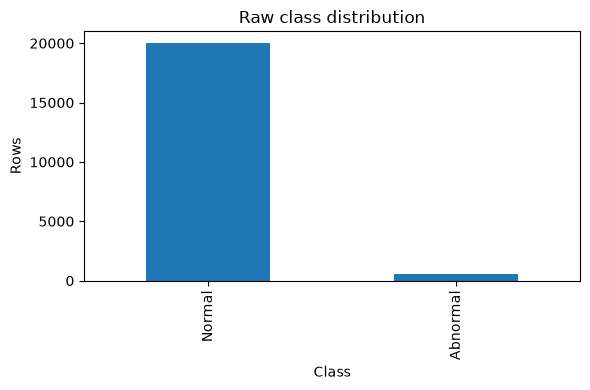

In [3]:
ax = class_ratio.plot(kind='bar', figsize=(6,4), title='Raw class distribution')
ax.set_ylabel('Rows')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()


### Interpretation

- Raw row 기준 정상 약 97%, 이상 약 3%로 불균형이 큽니다.
- 따라서 모델은 단순 Accuracy보다 **이상 Recall/F1과 PR-AUC**가 더 중요합니다.
- 원본 센서의 연속성을 무시하고 row 단위 random split을 하면 인접 샘플이 train/test에 동시에 들어갈 수 있으므로 시간 구조를 먼저 확인합니다.


## 2. Timestamp gap과 segmentation 기준

원본 데이터는 약 0.1초 간격으로 측정됩니다. `0.11초`는 물리적으로 특별한 숫자가 아니라, **0.1초 연속 샘플과 실제 수집 공백을 분리하기 위한 tolerance가 포함된 경계값**입니다.


In [4]:
normal_seg = create_segments(normal, GAP_THRESHOLD_SECONDS)
abnormal_seg = create_segments(abnormal, GAP_THRESHOLD_SECONDS)

def gap_summary(segmented):
    d = segmented['time_diff'].dropna()
    over = d[d > GAP_THRESHOLD_SECONDS]
    return {
        'rows': len(segmented),
        'segments': int(segmented['segment_id'].nunique()),
        'gap_0.1_count': int(np.isclose(d, 0.1, atol=1e-9).sum()),
        'gap_le_0.11_count': int((d <= GAP_THRESHOLD_SECONDS).sum()),
        'gap_gt_0.11_count': int((d > GAP_THRESHOLD_SECONDS).sum()),
        'min_gap_gt_0.11': float(over.min()) if len(over) else np.nan,
    }

gap_df = pd.DataFrame({
    'Normal': gap_summary(normal_seg),
    'Abnormal': gap_summary(abnormal_seg),
}).T
display(gap_df)


,rows,segments,gap_0.1_count,gap_le_0.11_count,gap_gt_0.11_count,min_gap_gt_0.11
Normal,20000.0,599.0,19400.0,19401.0,598.0,1.545
Abnormal,600.0,21.0,579.0,579.0,20.0,1.780


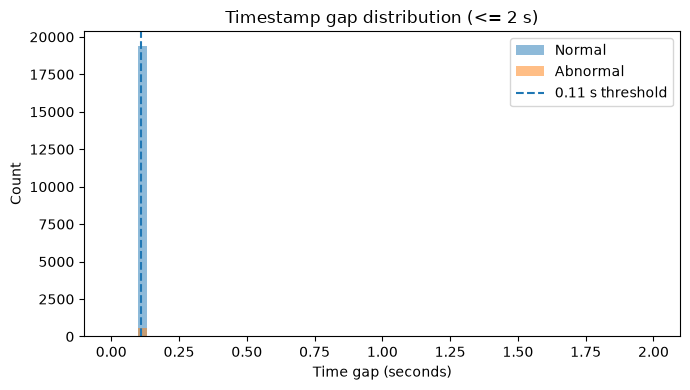

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
for name, df in [('Normal', normal_seg), ('Abnormal', abnormal_seg)]:
    gaps = df['time_diff'].dropna()
    gaps = gaps[gaps <= 2.0]
    ax.hist(gaps, bins=60, alpha=0.5, label=name)
ax.axvline(GAP_THRESHOLD_SECONDS, linestyle='--', linewidth=1.5, label='0.11 s threshold')
ax.set_xlabel('Time gap (seconds)')
ax.set_ylabel('Count')
ax.set_title('Timestamp gap distribution (<= 2 s)')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation

- 연속 측정 간격은 0.1초에 밀집되어 있고, 0.11초를 넘는 실제 gap은 훨씬 크게 벌어집니다.
- 따라서 `time_diff > 0.11`을 새로운 segment로 정의해도 0.1초 주변의 미세한 timestamp 차이를 과도하게 분할하지 않습니다.
- 이 기준으로 Normal 599개, Abnormal 21개의 측정 segment가 생성됩니다.


## 3. Segment length와 1초 window 선택

모델 입력은 segment 내부에서만 non-overlapping window로 만듭니다. Window가 segment 경계를 넘지 않도록 하며, 0.5초 / 1초 / 2초를 비교해 정보 보존과 분류 성능을 함께 확인했습니다.


In [6]:
segment_lengths = pd.concat([
    normal_seg.groupby('segment_id').size().rename('length').to_frame().assign(dataset='Normal'),
    abnormal_seg.groupby('segment_id').size().rename('length').to_frame().assign(dataset='Abnormal'),
]).reset_index(drop=True)

display(segment_lengths.groupby('dataset')['length'].describe()[['count','min','50%','mean','max']].round(2))


,count,min,50%,mean,max
dataset,,,,,
Abnormal,21.0,3.0,28.0,28.57,50.0
Normal,599.0,1.0,37.0,33.39,50.0


,window_size,window_seconds_approx,total_windows,normal_windows,abnormal_windows,normal_usable_segments,abnormal_usable_segments,precision_mean,recall_mean,f1_mean,f1_std,balanced_accuracy_mean,pr_auc_mean,pr_auc_std
0,5,0.5,3948,3834,114,570,18,0.9645,0.8864,0.9216,0.0276,0.9427,0.9823,0.0202
1,10,1.0,1873,1820,53,530,17,0.9818,0.9055,0.9405,0.0432,0.9525,0.9761,0.0271
2,20,2.0,749,728,21,452,13,1.0000,0.8600,0.9206,0.0736,0.9300,0.9900,0.0224


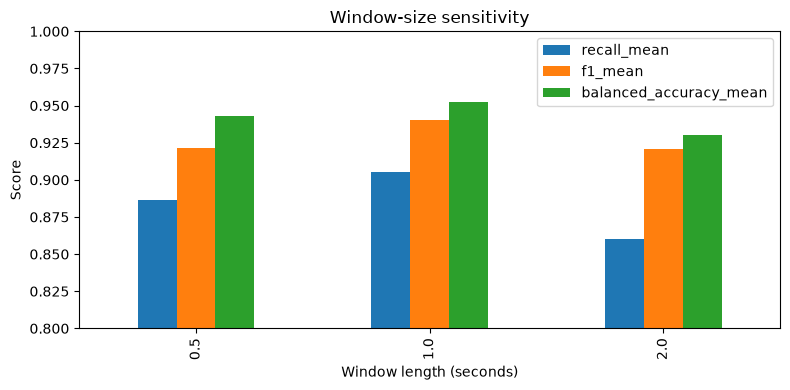

In [7]:
window_summary_path = RESULTS_DIR / 'window_sensitivity_summary.csv'
window_summary = pd.read_csv(window_summary_path)
display(window_summary.round(4))

ax = window_summary.plot(
    x='window_seconds_approx',
    y=['recall_mean','f1_mean','balanced_accuracy_mean'],
    kind='bar', figsize=(8,4)
)
ax.set_xlabel('Window length (seconds)')
ax.set_ylabel('Score')
ax.set_ylim(0.80, 1.0)
ax.set_title('Window-size sensitivity')
plt.tight_layout()
plt.show()


### Why 1 second?

- 0.5초는 abnormal segment를 더 많이 보존하지만 Recall/F1이 1초보다 낮았습니다.
- 2초는 Precision과 PR-AUC는 높았지만 usable abnormal segment가 13개로 줄고 Recall/F1 및 안정성이 떨어졌습니다.
- **1초 window가 Recall, F1, Balanced Accuracy에서 가장 균형이 좋았기 때문에 baseline window로 선택했습니다.**

단, 이것은 동일 개발 데이터의 Group CV에서 얻은 민감도 분석이며 다른 설비/수집 세션에서도 1초가 최적이라고 일반화하지 않습니다.


## 4. Feature engineering

각 1초 window에서 3개 센서별 `mean`, `std`, `RMS`, `min`, `max`를 계산해 총 15개 feature를 생성합니다. `peak-to-peak = max - min`은 정확한 선형 종속성이어서 최종 feature에서는 제외했습니다.


In [8]:
feature_df = build_feature_dataset(normal_seg, abnormal_seg, WINDOW_SIZE)
print('Feature dataset shape:', feature_df.shape)
print('Normal windows:', int((feature_df['label']==0).sum()))
print('Abnormal windows:', int((feature_df['label']==1).sum()))
print('Usable abnormal segments:', feature_df.loc[feature_df['label']==1, 'group_id'].nunique())

display(feature_df[['dataset','segment_id','window_in_segment'] + FEATURE_COLUMNS].head())


Feature dataset shape: (1873, 23)
Normal windows: 1820
Abnormal windows: 53
Usable abnormal segments: 17


,dataset,segment_id,window_in_segment,AI0_Vibration_mean,AI0_Vibration_std,AI0_Vibration_rms,AI0_Vibration_min,AI0_Vibration_max,AI1_Vibration_mean,AI1_Vibration_std,AI1_Vibration_rms,AI1_Vibration_min,AI1_Vibration_max,AI2_Current_mean,AI2_Current_std,AI2_Current_rms,AI2_Current_min,AI2_Current_max
0,Normal,1,1,0.003560,0.059079,0.056160,-0.102980,0.116967,-0.010006,0.170443,0.162006,-0.210895,0.258642,32.290700,163.141877,158.102606,-213.795930,217.004330
1,Normal,1,2,-0.023480,0.072572,0.072742,-0.111733,0.110246,-0.027812,0.161103,0.155345,-0.226471,0.197857,35.887449,162.221934,158.026166,-206.088810,217.325950
2,Normal,1,3,-0.027718,0.044534,0.050530,-0.085008,0.072439,0.002235,0.181460,0.172163,-0.266900,0.266851,-87.445997,121.549468,144.719205,-219.317340,138.879790
3,Normal,1,4,0.014945,0.095042,0.091395,-0.128888,0.191580,0.014745,0.169144,0.161140,-0.203526,0.275627,107.827402,92.080783,138.772231,-28.200987,219.931510
4,Normal,2,1,0.015623,0.063459,0.062197,-0.116100,0.098341,0.012843,0.150112,0.142987,-0.141934,0.244895,-104.313195,88.233090,133.745329,-213.144690,28.972868


In [9]:
sensor_summary = feature_df.groupby('dataset')[
    ['AI0_Vibration_rms','AI1_Vibration_rms','AI2_Current_rms']
].agg(['mean','median','std']).round(4)
display(sensor_summary)


AI0_Vibration_rms                 AI1_Vibration_rms                  \
                      mean  median     std              mean  median     std   
dataset                                                                        
Abnormal            0.3351  0.2806  0.2882            0.2066  0.1834  0.1079   
Normal              0.0659  0.0644  0.0246            0.1035  0.0870  0.0591   

         AI2_Current_rms                     
                    mean    median      std  
dataset                                      
Abnormal        139.4748  105.0511  90.7183  
Normal          117.2269   99.7233  37.3357

## 5. Validation design — 왜 StratifiedGroupKFold인가

`StratifiedKFold`는 클래스 비율은 유지하지만 동일 segment의 인접 window가 train/test에 동시에 들어갈 수 있습니다. 이 데이터에서는 인접 window가 같은 측정구간에서 만들어지므로 이런 분할은 성능을 낙관적으로 만들 수 있습니다.

따라서 `group_id = dataset + segment_id`로 묶고 **StratifiedGroupKFold**를 사용해:

1. 동일 segment가 train/test에 동시에 들어가지 않게 하고
2. 정상/이상 비율도 가능한 한 유지합니다.

평가 코드에는 실제로 group overlap이 존재하면 오류를 발생시키는 체크도 포함되어 있습니다.


## 6. Baseline model comparison

선형 baseline(Logistic Regression), 비선형 tree baseline(Random Forest), boosting model(CatBoost)을 같은 15개 feature와 동일한 Group 5-Fold split에서 비교합니다.


In [10]:
baseline_fold_metrics = evaluate_models(feature_df)
baseline_summary = (
    baseline_fold_metrics.groupby('model')
    .agg(
        precision=('precision','mean'),
        recall=('recall','mean'),
        f1=('f1','mean'),
        balanced_accuracy=('balanced_accuracy','mean'),
        pr_auc=('pr_auc','mean'),
        false_negative_count=('false_negative_count','mean'),
        false_positive_count=('false_positive_count','mean'),
    )
    .sort_values('f1', ascending=False)
)
display(baseline_summary.round(4))


,precision,recall,f1,balanced_accuracy,pr_auc,false_negative_count,false_positive_count
model,,,,,,,
CatBoost,0.9818,0.9055,0.9405,0.9525,0.9750,1.0,0.2
Random Forest,1.0000,0.8691,0.9272,0.9345,0.9775,1.4,0.0
Logistic Regression,0.7312,0.9036,0.8009,0.9466,0.9253,1.0,3.8


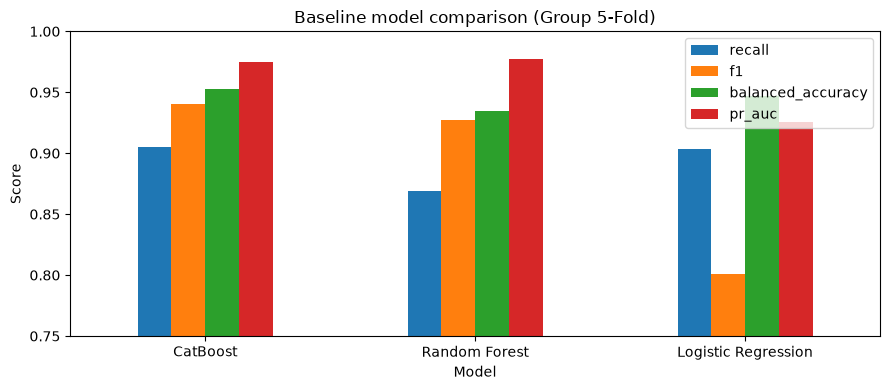

In [11]:
ax = baseline_summary[['recall','f1','balanced_accuracy','pr_auc']].plot(
    kind='bar', figsize=(9,4), ylim=(0.75,1.0),
    title='Baseline model comparison (Group 5-Fold)'
)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretation

- Logistic Regression은 이상 Recall이 높지만 False Positive가 상대적으로 많았습니다.
- Random Forest는 Precision이 높지만 Recall이 낮아 일부 이상을 놓쳤습니다.
- CatBoost는 Precision/Recall 균형이 좋아 이후 반복 Group CV와 오류분석의 개발 후보로 사용했습니다.

여기서 '최종 모델이 절대적으로 우수하다'고 주장하기보다, **현재 데이터와 검증 조건에서의 개발 후보**로 해석합니다.


## 7. Repeated Group CV — split 민감도 확인

abnormal usable segment가 17개뿐이므로 하나의 5-Fold 결과만 제시하면 특정 split의 우연에 민감할 수 있습니다. 10개 random state × 5-Fold로 반복해 변동성을 확인합니다.


In [12]:
window_metrics, segment_metrics = evaluate_repeated_group_cv(feature_df)

print('Window-level repeated Group CV')
display(summarize(window_metrics).drop(index='split_random_state', errors='ignore').round(4))

print('Segment-level mean aggregation (reference only)')
display(summarize(segment_metrics).drop(index='split_random_state', errors='ignore').round(4))


Window-level repeated Group CV


,mean,std,min,max
abnormal_precision,0.9760,0.0123,0.9608,1.0000
abnormal_recall,0.9151,0.0133,0.8868,0.9245
abnormal_f1,0.9445,0.0082,0.9307,0.9608
balanced_accuracy,0.9572,0.0066,0.9431,0.9623
pr_auc,0.9794,0.0031,0.9749,0.9849


Segment-level mean aggregation (reference only)


,mean,std,min,max
abnormal_precision,1.0000,0.0000,1.0000,1.0
abnormal_recall,0.9941,0.0186,0.9412,1.0
abnormal_f1,0.9970,0.0096,0.9697,1.0
balanced_accuracy,0.9971,0.0093,0.9706,1.0
false_negative_segment_count,0.1000,0.3162,0.0000,1.0
false_positive_segment_count,0.0000,0.0000,0.0000,0.0


### Main performance to report

- Window-level F1: 약 **0.944 ± 0.008**
- Window-level Recall: 약 **0.915 ± 0.013**
- Window-level Balanced Accuracy: 약 **0.957 ± 0.007**
- PR-AUC: 약 **0.979 ± 0.003**

Segment-level aggregation은 높은 성능이 나왔지만 usable abnormal segment가 17개뿐이라 **보조 결과**로만 해석합니다.


## 8. Error analysis — 평균점수보다 모델이 어디서 흔들리는가

### Segment 16

원래 반복 분석에서 Segment 16은 5개 window의 평균 이상확률이 약 `0.014 → 0.071 → 0.594 → 0.993 → 0.999`로 변했습니다. 즉 segment 내부가 균일하지 않았고, 단순 평균 aggregation은 앞쪽 정상형 window 때문에 후반 이상 신호를 희석할 수 있었습니다.

이 현상을 실제 고장 시작시점이라고 단정하지 않고 **segment 내부 transition pattern**으로만 해석합니다.


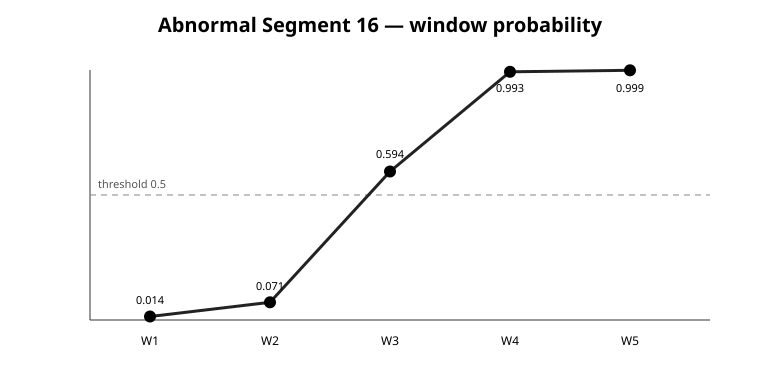

In [13]:
segment16_svg = RESULTS_DIR / 'figures' / 'segment16_transition.svg'
if segment16_svg.exists():
    display(SVG(filename=str(segment16_svg)))


### Segment 20

Segment 20은 진동은 상대적으로 낮지만 전류 level이 크게 다른 사례였습니다. 일부 split에서 False Negative가 발생했고, 학습 구성에 따라 예측확률이 크게 흔들렸습니다.

아래 SHAP 결과는 **최종 15-feature tuned model의 global importance가 아니라, 초기 18-feature baseline에서 Segment 20 False Negative를 설명한 local 분석**입니다.


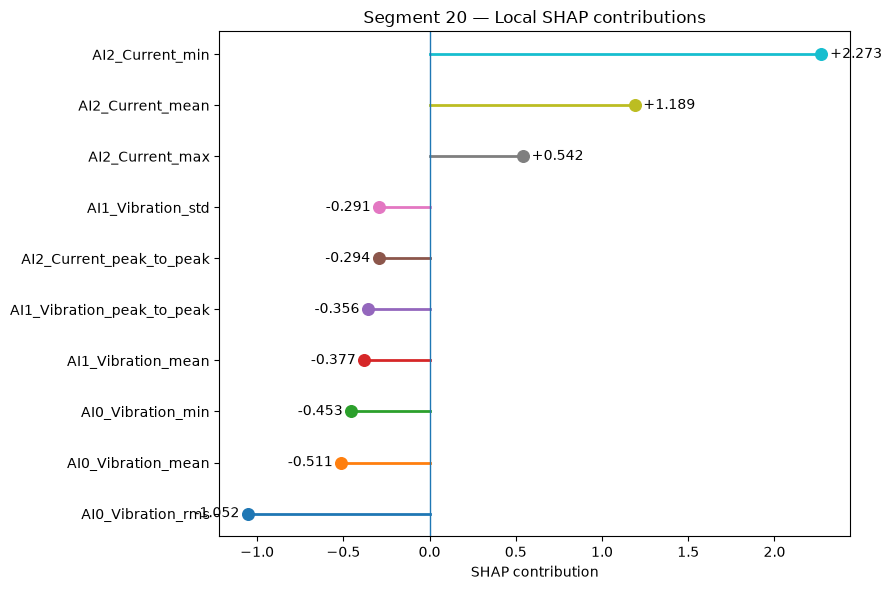

In [16]:
# SHAP 결과 불러오기
shap_path = RESULTS_DIR / "shap_segment20_baseline18.csv"
shap_seg20 = pd.read_csv(shap_path)

# 절댓값 기준 상위 10개
top = (
    shap_seg20
    .sort_values("absolute_shap_value", ascending=False)
    .head(10)
    .sort_values("shap_value")
    .reset_index(drop=True)
)

y_pos = np.arange(len(top))

fig, ax = plt.subplots(figsize=(9, 6))

# 0에서 SHAP 값까지 선 + 점
for i, row in top.iterrows():
    x = row["shap_value"]

    ax.plot([0, x], [i, i], linewidth=2)
    ax.scatter(x, i, s=70)

    offset = 0.05 if x >= 0 else -0.05

    ax.text(
        x + offset,
        i,
        f"{x:+.3f}",
        va="center",
        ha="left" if x >= 0 else "right",
        fontsize=10
    )

ax.axvline(0, linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(top["feature"])

ax.set_xlabel("SHAP contribution")
ax.set_ylabel("")
ax.set_title("Segment 20 — Local SHAP contributions")

plt.tight_layout()
plt.show()

### SHAP interpretation

- `AI2_Current_min/mean/max`는 이상 방향으로 강하게 기여했습니다.
- 반대로 낮은 `AI0_Vibration_rms/mean/min`은 정상 방향으로 기여했습니다.
- 즉 모델은 **고전류 신호와 저진동 신호가 충돌하는 패턴**에서 흔들렸습니다.

SHAP은 모델의 예측 기여도를 설명할 뿐 실제 고장 원인을 증명하지 않습니다.


## 9. Tuning decision

소규모 CatBoost tuning에서 `depth=4`, `learning_rate=0.03`, `iterations=400` 설정이 개발 후보가 되었습니다.

Baseline 대비 개선 폭은 크지 않았습니다.

- Window F1: 약 `0.937 → 0.944`
- PR-AUC: 약 `0.977 → 0.979`

따라서 이 프로젝트에서는 hyperparameter search 자체보다 **leakage-safe validation, split 안정성, 오류 사례 분석**을 더 중요한 결과로 봅니다.


## 10. Limitations

- 1초 기준 usable abnormal segment가 **17개**로 매우 적습니다.
- 정상/이상 데이터가 서로 다른 수집 세션이라면 **session/date confounding** 가능성이 있습니다.
- 현재 label로 실제 고장 시작시점, 고장 유형, RUL을 확정할 수 없습니다.
- feature 선택, aggregation, tuning을 개발 CV를 보며 결정했으므로 완전 독립 test 성능이 아닙니다.
- 설비 중요도, 안전등급, 생산손실, 정비 결과가 없어 실제 정비 우선순위를 모델이 자동 결정할 수 없습니다.


## 11. Field action proposal

현재 모델의 역할은 **정비 결정을 자동 확정하는 것**이 아니라 이상 가능성이 높은 구간을 선별해 현장 판단을 지원하는 것입니다.

`센서 → 이상 탐지 → 표준 점검 템플릿 → 현장 담당자 판단 → 조치 → 결과 저장 → 향후 모델 고도화`

추가 현장 데이터가 확보되면 설비 중요도, 안전 영향, 생산 영향, 정비이력과 결합해 실제 점검 우선순위 의사결정으로 확장할 수 있습니다. 매뉴얼/정비이력 검색 RAG도 이 단계에서 의사결정 지원 도구로 연결할 수 있지만, 현재 프로젝트에서 구현된 기능은 아닙니다.


## 12. Portfolio takeaway

이 프로젝트에서 강조할 핵심은 단순히 `CatBoost F1 0.944`가 아닙니다.

> **연속 센서 데이터의 누수 가능성을 고려해 segment 기반 검증 구조를 설계하고, 불균형 데이터에서 반복 Group CV와 오류 사례 분석으로 모델의 취약 패턴을 확인한 뒤 현장 점검 프로세스까지 연결했다.**

이 notebook의 수치는 개발 단계 교차검증 결과이며 실제 생산환경 성능을 의미하지 않습니다.
